In [4]:
!pip install wordcloud matplotlib 

  Using cached pymorphy3-2.0.6-py3-none-any.whl.metadata (2.4 kB)
  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
  Using cached dawg2_python-0.9.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached pymorphy3_dicts_ru-2.4.417150.4580142-py2.py3-none-any.whl.metadata (2.0 kB)
Using cached pymorphy3-2.0.6-py3-none-any.whl (53 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/8.4 MB 4.9 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.4 MB 6.6 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.4 MB 7.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.3/8.4 MB 7.7 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.4 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 7.5 MB/s eta 0:00:00

   ---------------------------------------- 0/4 [pymorphy3-dicts-ru]
   -------------------- ------------------- 2/4 [

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import pymorphy3
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')


In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))
stop_words.update(['это', 'прошу', 'пожалуйста', 'спасибо', 'очень', 'наш', 'свой'])
morph = pymorphy3.MorphAnalyzer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
df = pd.read_csv('Petitions.csv')
df = df[['public_petition_text', 'reason_category']].dropna()

### 1. Предобработка текста

In [5]:
from functools import lru_cache

@lru_cache(maxsize=10000)
def get_lemma(word):
    return morph.parse(word)[0].normal_form
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё\s]', ' ', text)  
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    clean_words = []
    for word in words:
        if word not in stop_words and len(word) > 2:
            lemma = get_lemma(word)
            clean_words.append(lemma)      
    return ' '.join(clean_words)

print("Предобработка текста")
df['clean_text'] = df['public_petition_text'].apply(preprocess_text)

df = df[df['clean_text'].str.strip() != '']

print(f"Предобработка завершена! Осталось записей: {len(df)}")
unique_categories = df['reason_category'].unique()
total_categories = len(unique_categories)
print(f"Всего категорий в датасете: {total_categories}")
print(df[['clean_text', 'reason_category']].head())

Предобработка текста
Предобработка завершена! Осталось записей: 59889
Всего категорий в датасете: 15
                                          clean_text  reason_category
0                                        снег дорога  Благоустройство
1                   очистить кабельный киоск реклама  Благоустройство
2  просить убрать дерево кустарник который выйти ...  Благоустройство
3  неудовлетворительный состояние парадный надпис...   Содержание МКД
4                                           граффити  Благоустройство


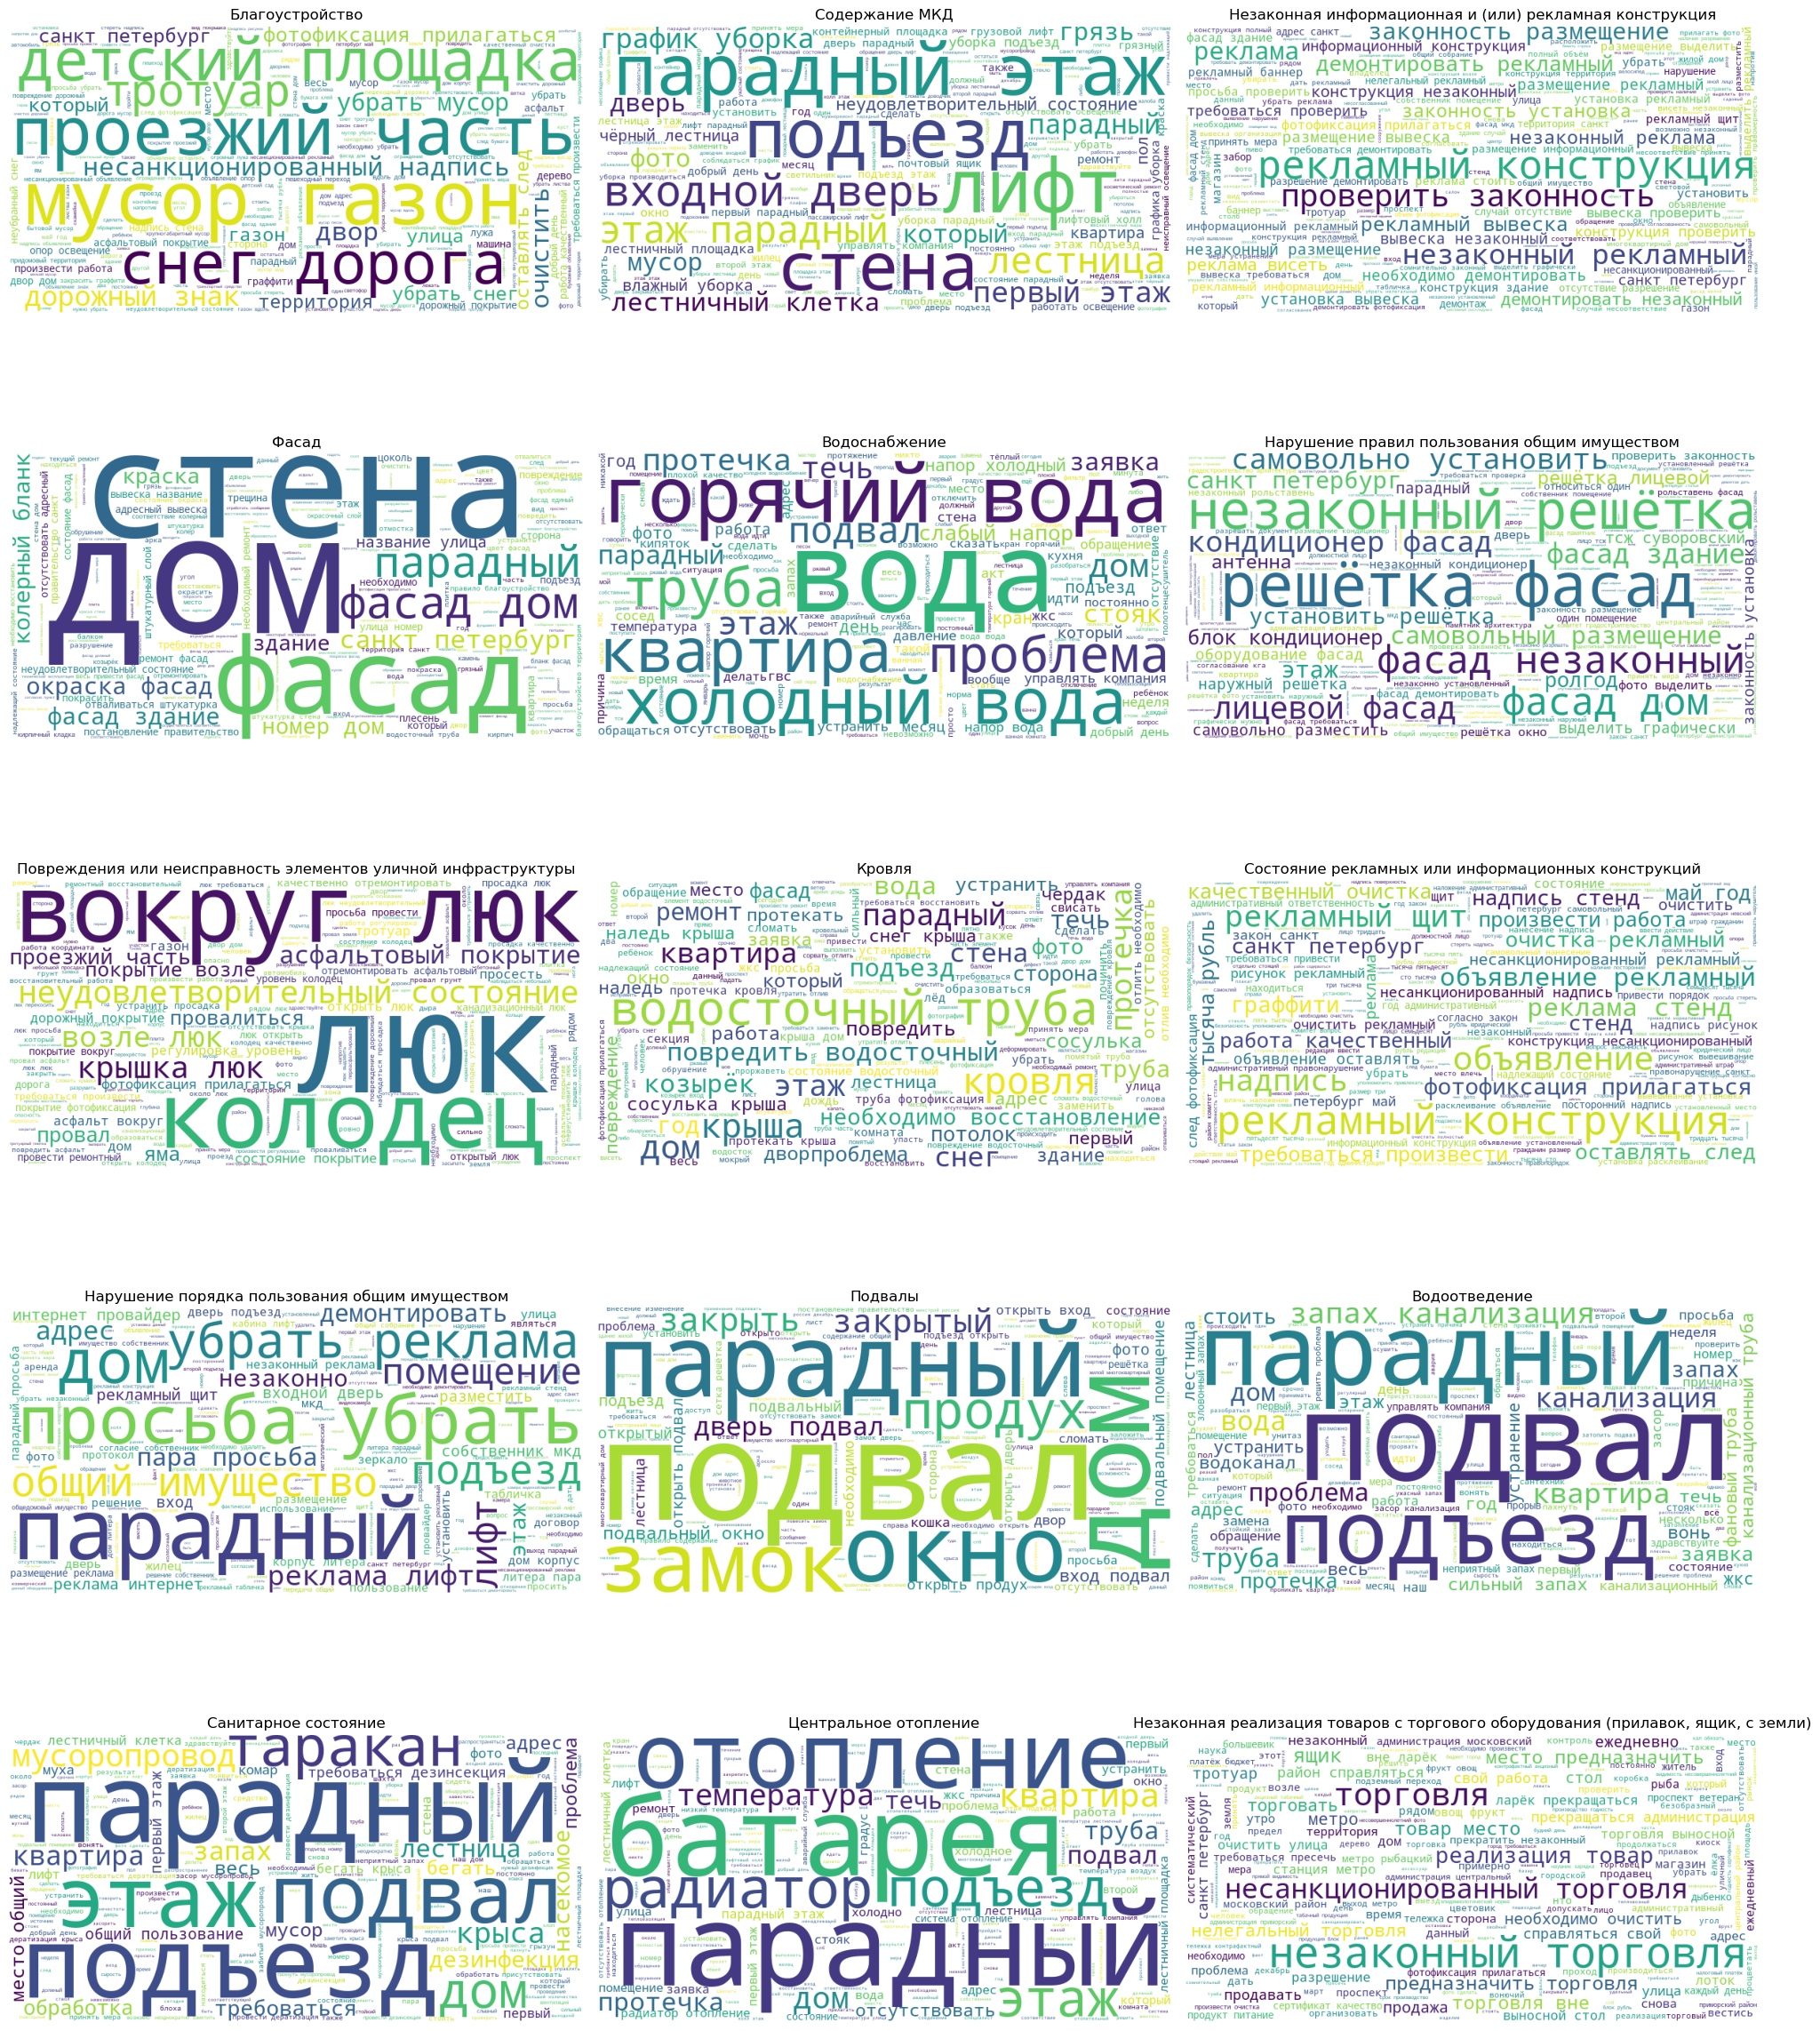

In [9]:
import math
from wordcloud import WordCloud
import matplotlib.pyplot as plt

categories = df['reason_category'].unique()
cols = 3
rows = math.ceil(len(categories) / cols)

plt.figure(figsize=(20, 5 * rows))
for i, cat in enumerate(categories, 1):
    text = ' '.join(df[df['reason_category'] == cat]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.subplot(rows, cols, i)
    plt.imshow(wordcloud)
    plt.title(cat)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

category_docs = df.groupby('reason_category')['clean_text'].apply(lambda x: ' '.join(x))

tfidf = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf.fit_transform(category_docs)
feature_names = tfidf.get_feature_names_out()


for i, category in enumerate(category_docs.index):
    row = tfidf_matrix.getrow(i).toarray()[0]

    top_indices = row.argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    
    print(f"категория: {category}")
    print(f"слова: {', '.join(top_words)}")
    print()

категория: Благоустройство
слова: мусор, надпись, газон, снег, убрать, дом, граффити, дорога, дорожный, объявление

категория: Водоотведение
слова: канализация, запах, подвал, труба, парадный, канализационный, подъезд, вода, квартира, проблема

категория: Водоснабжение
слова: вода, горячий, холодный, напор, кран, стояк, квартира, труба, проблема, слабый

категория: Кровля
слова: водосточный, труба, крыша, кровля, снег, протечка, дом, сосулька, повредить, козырёк

категория: Нарушение порядка пользования общим имуществом
слова: реклама, парадный, лифт, рекламный, дом, подъезд, собственник, убрать, общий, имущество

категория: Нарушение правил пользования общим имуществом
слова: фасад, решётка, незаконный, кондиционер, дом, самовольно, демонтировать, размещение, самовольный, рольставень

категория: Незаконная информационная и (или) рекламная конструкция
слова: рекламный, конструкция, реклама, незаконный, вывеска, законность, демонтировать, размещение, проверить, установка

категория: Нез

--- Оценка качества моделей ---
Логистическая регрессия - Accuracy: 0.8565
Случайный лес - Accuracy: 0.8844
Наивный Байес - Accuracy: 0.8610

Лучшая модель: Случайный лес


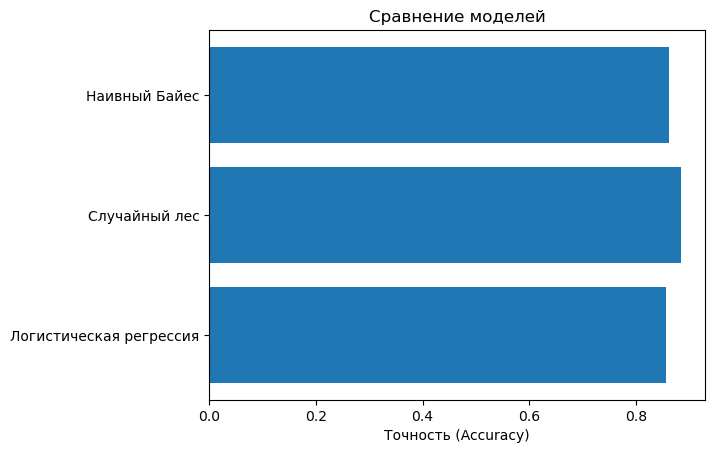

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import joblib
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['reason_category'], test_size=0.2, random_state=42, stratify=df['reason_category']
)

# Векторизация
vectorizer = TfidfVectorizer(max_features=10000, min_df=3, max_df=0.9)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Обучение 3 моделей
models = {
    "Логистическая регрессия": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Случайный лес": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Наивный Байес": MultinomialNB()
}

best_model = None
best_acc = 0
best_model_name = ""

print("--- Оценка качества моделей ---")
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    print(f"{name} - Accuracy: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name

print(f"\nЛучшая модель: {best_model_name}")
# Сохраняем модель и векторизатор для API
joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump(best_model, 'best_model.pkl')

names = list(models.keys())
scores = [accuracy_score(y_test, models[n].predict(X_test_vec)) for n in names]

# barh делает полоски горизонтальными
plt.barh(names, scores)

plt.xlabel('Точность (Accuracy)')
plt.title('Сравнение моделей')
plt.show()

In [16]:
import requests
from bs4 import BeautifulSoup
import time
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import joblib
# --- ПУНКТ 6. ПАРСИНГ НАДЕЖНОГО САЙТА ---
def parse_real_data(target_count=500):
    print(f"Начинаем парсинг... Цель: {target_count} текстов.")
    parsed_texts = []
    page = 1
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/115.0.0.0 Safari/537.36'
    }
    while len(parsed_texts) < target_count:
        url = f"https://habr.com/ru/news/page{page}/"
        try:
            response = requests.get(url, headers=headers, timeout=10)
            if response.status_code != 200:
                print(f"Ошибка доступа к странице. Код: {response.status_code}")
                break       
            soup = BeautifulSoup(response.text, 'html.parser')
            
            posts = soup.find_all('p')
            
            for post in posts:
                text = post.get_text(strip=True)
                if 80 < len(text) < 1000:
                    parsed_texts.append(text)
                    
                if len(parsed_texts) >= target_count:
                    break
                        
            print(f"Спарсена страница {page}. Собрано: {len(parsed_texts)}/{target_count}")
            page += 1
            time.sleep(0.5)
            
        except Exception as e:
            print(f"Ошибка при парсинге: {e}")
            break
            
    df_parsed = pd.DataFrame({'parsed_text': parsed_texts}).drop_duplicates().reset_index(drop=True)
    print(f"Парсинг завершен! Уникальных текстов: {len(df_parsed)}")
    return df_parsed

parsed_df = parse_real_data(target_count=500)

print("\nОчистка спарсенных данных...")
parsed_df['clean_text'] = parsed_df['parsed_text'].apply(preprocess_text)
parsed_df = parsed_df[parsed_df['clean_text'] != ''].reset_index(drop=True)


# ДООБУЧЕНИE
print("\n--- Запуск процесса дообучения модели ---")
iterations = 3
current_train_X = X_train.tolist()
current_train_y = y_train.tolist()

for i in range(iterations):
    print(f"\n[ Итерация дообучения {i+1} из {iterations} ]")
    if parsed_df.empty:
        print("Спарсенные данные закончились.")
        break
    X_parsed_vec = vectorizer.transform(parsed_df['clean_text'])
    
    probs = best_model.predict_proba(X_parsed_vec)
    preds = best_model.predict(X_parsed_vec)
    max_probs = np.max(probs, axis=1)
    
    condition = (max_probs > 0.8) | (max_probs < 0.2)
    indices_to_move = np.where(condition)[0]
    
    print(f"Отобрано записей (уверенность >0.8 или <0.2): {len(indices_to_move)} из {len(parsed_df)}")
    
    if len(indices_to_move) == 0:
        print("Нет подходящих текстов под условие. Остановка.")
        break
    texts_to_add = parsed_df.iloc[indices_to_move]['clean_text'].tolist()
    labels_to_add = preds[indices_to_move].tolist()
    current_train_X.extend(texts_to_add)
    current_train_y.extend(labels_to_add)
    parsed_df = parsed_df.drop(indices_to_move).reset_index(drop=True)

    vectorizer = TfidfVectorizer(max_features=10000, min_df=3, max_df=0.9)
    X_new_train_vec = vectorizer.fit_transform(current_train_X)
    best_model.fit(X_new_train_vec, current_train_y)

    X_test_vec_new = vectorizer.transform(X_test)
    new_acc = accuracy_score(y_test, best_model.predict(X_test_vec_new))
    print(f"Новое качество (Accuracy) на тестовой выборке: {new_acc:.4f}")

Начинаем парсинг... Цель: 500 текстов.
Спарсена страница 1. Собрано: 24/500
Спарсена страница 2. Собрано: 48/500
Спарсена страница 3. Собрано: 76/500
Спарсена страница 4. Собрано: 98/500
Спарсена страница 5. Собрано: 126/500
Спарсена страница 6. Собрано: 159/500
Спарсена страница 7. Собрано: 195/500
Спарсена страница 8. Собрано: 218/500
Спарсена страница 9. Собрано: 244/500
Спарсена страница 10. Собрано: 277/500
Спарсена страница 11. Собрано: 302/500
Спарсена страница 12. Собрано: 329/500
Спарсена страница 13. Собрано: 363/500
Спарсена страница 14. Собрано: 386/500
Спарсена страница 15. Собрано: 415/500
Спарсена страница 16. Собрано: 459/500
Спарсена страница 17. Собрано: 486/500
Спарсена страница 18. Собрано: 500/500
Парсинг завершен! Уникальных текстов: 500

Очистка спарсенных данных...

--- Запуск процесса дообучения модели ---

[ Итерация дообучения 1 из 3 ]
Отобрано записей (уверенность >0.8 или <0.2): 13 из 500
Новое качество (Accuracy) на тестовой выборке: 0.8830

[ Итерация доо